# Complaint Type Visualization Notebook for NYC 311 Calls Data

## Regenerated results

The outputs below were regenerated on **2026-09-17** from the locally recovered
`Project-3_NYC_311_Calls.pkl` dataset. The source contains **33,780,977 rows**
covering **2010-01-01 through 2023-08-04**.

These are reproducible replacement results, not the missing historical output bytes.
The source file SHA-256 is `9b60bc9284a94d2310f9e98383d3f9e7183f07469902a4433837a77844974a56`.


## Data loading

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Full-data reproduction (place the recovered PKL beside this notebook)
import pandas as pd

data = pd.read_pickle('Project-3_NYC_311_Calls.pkl')
data = data.rename(columns={
    'Complaint Type': 'complaint_type',
    'Borough': 'borough',
    'Created Date': 'created_date',
})
data['created_date'] = pd.to_datetime(data['created_date'])
print(f'{len(data):,} rows loaded')


33,780,977 rows loaded


## Complaint type summary

In [ ]:
summary = data['complaint_type'].value_counts().head(20).to_frame('Complaints')
summary['Share'] = (summary['Complaints'] / data['complaint_type'].count()).map(lambda x: f'{x:.2%}')
summary

,Complaints,Share
Noise - Residential,3131834,9.27%
Illegal Parking,2110646,6.25%
HEAT/HOT WATER,1983520,5.87%
Blocked Driveway,1439795,4.26%
Street Condition,1212154,3.59%
Street Light Condition,1115391,3.30%
Noise - Street/Sidewalk,1101122,3.26%
Request Large Bulky Item Collection,1073753,3.18%
PLUMBING,890888,2.64%
HEATING,887869,2.63%


### Bar chart

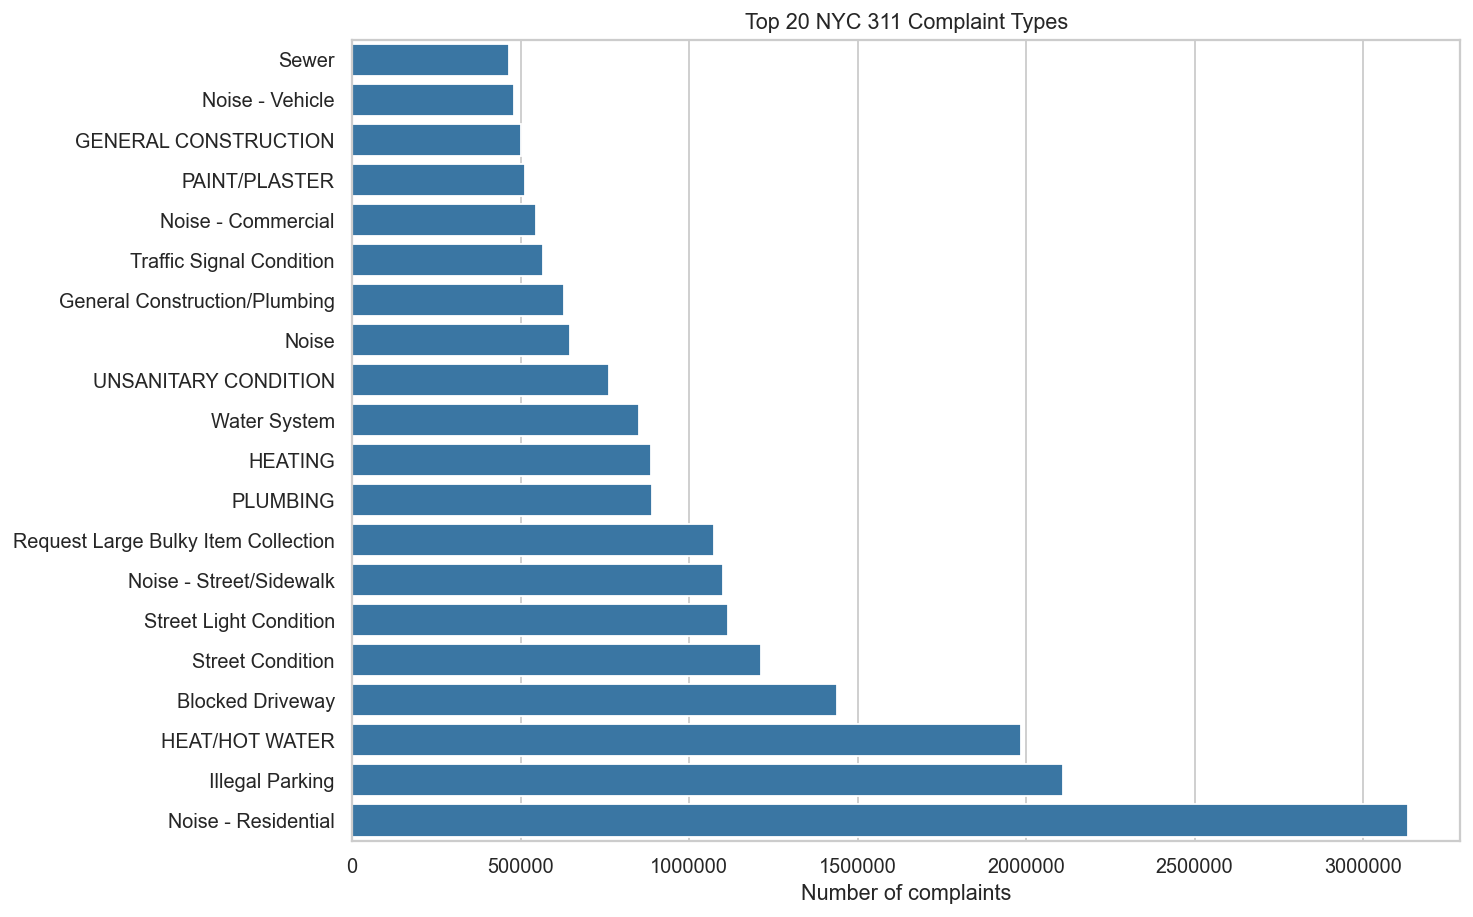

In [ ]:
complaint_counts = data['complaint_type'].value_counts()
top_complaints = complaint_counts.head(20)
plt.figure(figsize=(11, 8))
sns.barplot(x=top_complaints.values, y=top_complaints.index, color='#2878B5')
plt.title('Top 20 NYC 311 Complaint Types')
plt.xlabel('Number of complaints')
plt.ylabel('')
plt.show()


### Pie chart

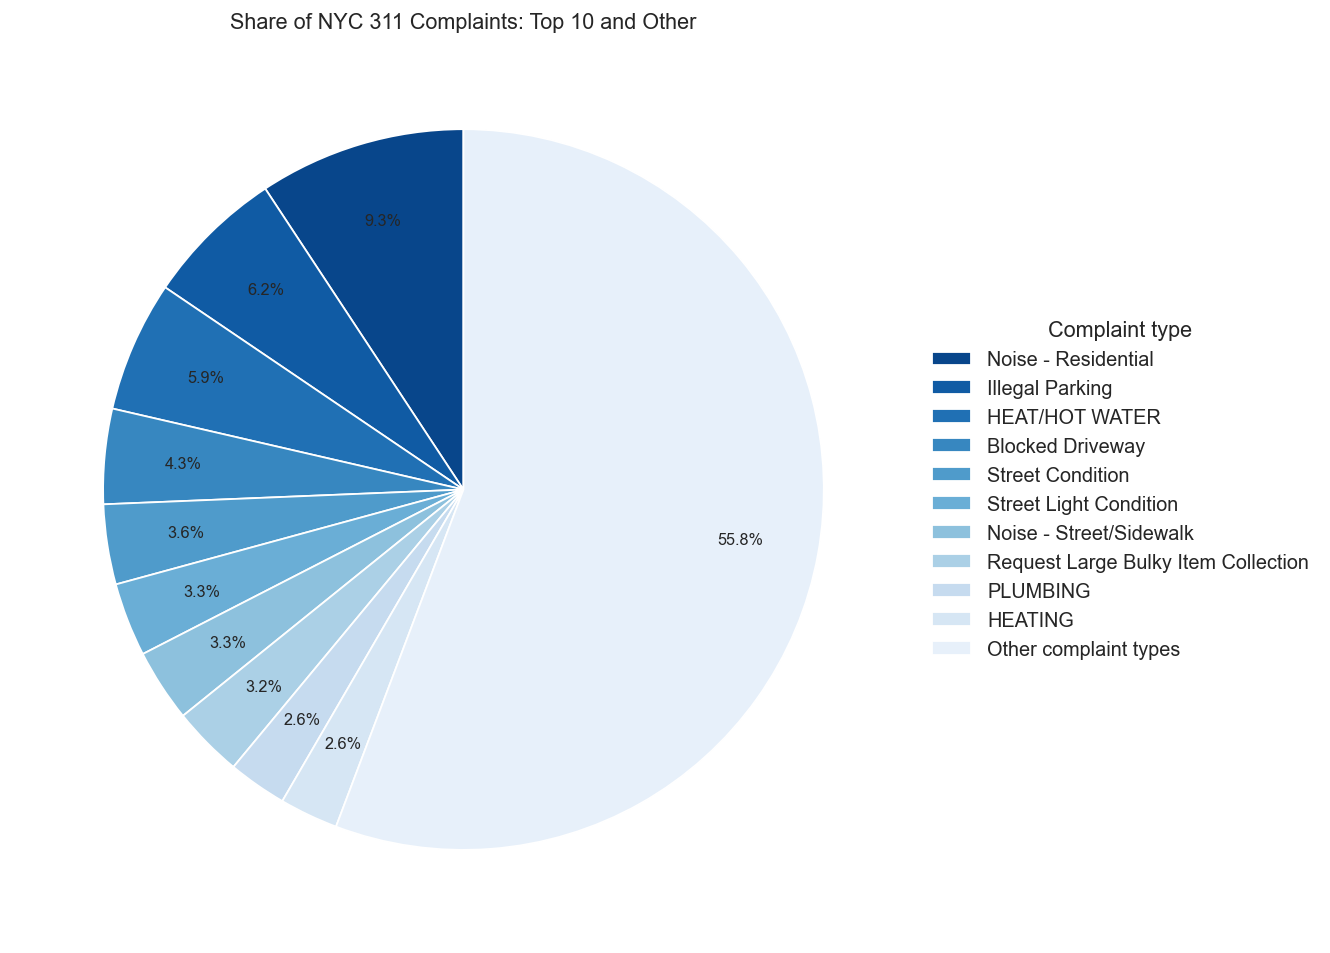

In [ ]:
top_10 = complaint_counts.head(10)
pie_counts = pd.concat([
    top_10,
    pd.Series({'Other complaint types': complaint_counts.iloc[10:].sum()})
])
plt.figure(figsize=(9, 9))
plt.pie(pie_counts.values, labels=pie_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Share of NYC 311 Complaints: Top 10 and Other')
plt.show()


## Borough-level analysis

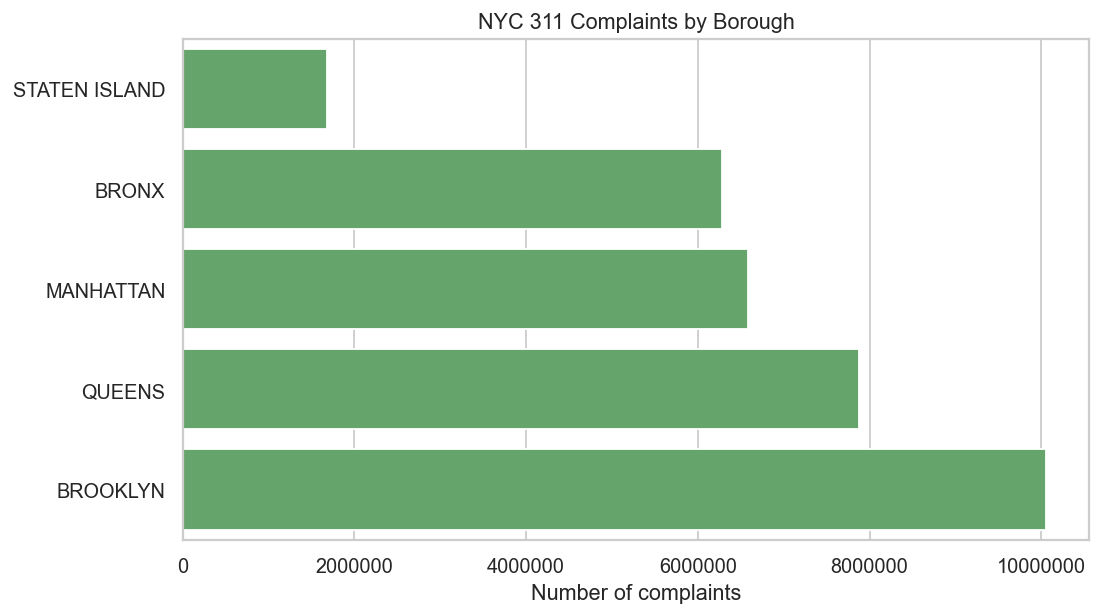

In [ ]:
borough_counts = data['borough'].value_counts().drop(labels=['Unspecified'], errors='ignore')
plt.figure(figsize=(9, 5))
sns.barplot(x=borough_counts.values, y=borough_counts.index, color='#5AAE61')
plt.title('NYC 311 Complaints by Borough')
plt.xlabel('Number of complaints')
plt.ylabel('')
plt.show()


## Time-series analysis

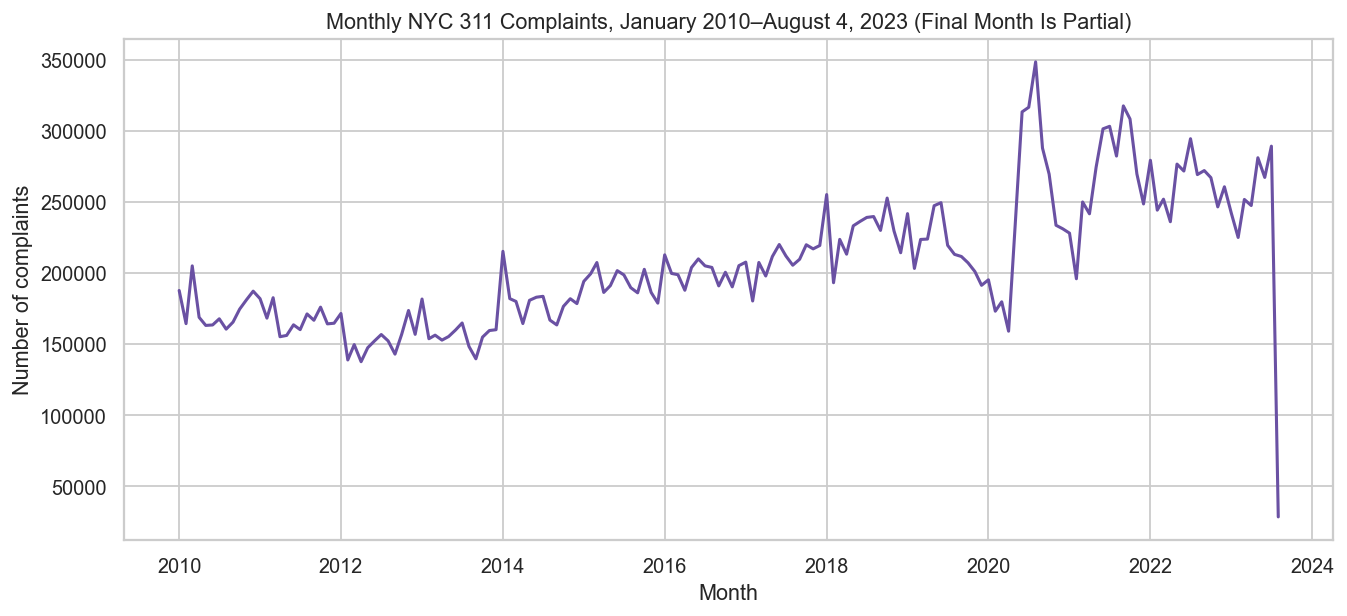

In [ ]:
monthly_counts = data.set_index('created_date').resample('MS')['complaint_type'].count()
plt.figure(figsize=(12, 5))
monthly_counts.plot(color='#6A51A3')
plt.title('Monthly NYC 311 Complaints, January 2010–August 4, 2023 (Final Month Is Partial)')
plt.xlabel('Month')
plt.ylabel('Number of complaints')
plt.show()
